예제 실행 및 시각화를 위해 공통 라이브러리를 불러온다.
(공통 라이브러리에 대한 설명은 `code_reference/README.md` 파일을 참조)

In [1]:
# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz
# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib에서 한글 폰트 사용 설정
common.set_korean_plot_env()

다음 셀은 결과 재현성을 보장하기 위해서 시드를 고정한다. 여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.

In [2]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 3-2 다층 퍼셉트론으로 구현한 XOR 게이트

본 노트북은 본문 3-2절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 파이토치 고수준 API를 활용해 다층 퍼셉트론 모델 정의하기
- Adam 옵티마이저를 사용해 모델 학습하기
- 다층 퍼셉트론 모델의 결정 경계 분석

본문의 모델 3의 구현에 해당되며, 모델 3의 제시문은 다음과 같다.

> **모델 3. XOR 시뮬레이터 모델**
>
> 두 개의 숫자를 입력받아 하나의 숫자를 출력하는 다음과 같은 함수가 있다.
>
>   | 입력 1($x_1$) | 입력 2($x_2$) | 출력($y$) |
>   |:-----:|:-----:|:---:|
>   | 0 | 0 | 0 |
>   | 0 | 1 | 1 |
>   | 1 | 0 | 1 |
>   | 1 | 1 | 0 |
>
> 데이터를 학습해 이와 같이 동작하는 모델을 만들어 보자.

## 다층 퍼셉트론 모델 클래스 정의

- 입력층과 출력층으로만 구성된 퍼셉트론 모델에서 은닉층을 추가해 다층 퍼셉트론 모델 정의
- 은닉층: 선형 계층(`nn.Linear`)과 시그모이드 활성화 계층(`nn.Sigmoid`)을 정의해 `forward()`에서 데이터 흐름 순서대로 입력층과 출력층 사이에 배치
- 활성화 계층은 파라미터가 없는 함수형 계층으로, 객체 하나만 만들어 여러 번 재사용 가능

In [3]:
########################################################################################
# 코드 3-1 - 뉴런이 2개인 은닉층 하나를 추가한 다층 퍼셉트론 모델 클래스
########################################################################################
import torch
import torch.nn as nn

# 은닉층 하나를 가진 다층 퍼셉트론 모델 클래스
class MLP(nn.Module):
    # 은닉층과 출력층 두 개의 선형 계층, 시그모이드 활성화 계층 정의
    def __init__(self):
        super().__init__()
        self.hidden_layer = nn.Linear(2, 2)     # 은닉층: in_features=2, out_features=2
        self.output_layer = nn.Linear(2, 1)     # 출력층: in_features=2, out_features=1
        # 시그모이드 활성화 계층은 파라미터가 없으므로 반복 재사용 가능
        self.activation = nn.Sigmoid()          # 활성화 계층

    # 데이터 흐름 순서(은닉층, 활성화 계층, 출력층, 활성화 계층)대로 모델을 조립
    def forward(self, x):
        x = self.hidden_layer(x)                # 은닉층: (4, 2) -> (4, 2) 
        x = self.activation(x)                  # 활성화 계층: 형태가 바뀌지 않음 
        x = self.output_layer(x)                # 출력층: (4, 2) -> (4, 1)
        x = self.activation(x)                  # 활성화 계층
        return x      

- 연결된 두 계층은 이전 계층의 출력과 이후 계층의 입력의 형태가 같아야 한다.
- 다음 예제에서 첫 번째 활성화 계층의 출력은 `(N, 3)` 형태이지만, 출력층은 `(N, 2)` 형태의 입력을 받음
    - 모델 객체는 생성할 수 있으나 호출시 예외 발생

In [4]:
########################################################################################
# 코드 3-2 - 연결된 두 계층은 출력과 입력 텐서의 형태가 같아야 한다
########################################################################################

class WrongMLP(nn.Module):                     # 잘못 만들어진 MLP 모델 클래스
    def __init__(self):
        super().__init__()
        self.hidden_layer = nn.Linear(2, 3)    # 출력이 세 개인 은닉층
        self.output_layer = nn.Linear(2, 1)    # 입력이 두 개인 출력층
        self.activation = nn.Sigmoid()

    def forward(self, x):
        x = self.hidden_layer(x)               # (N, 3) 형태의 텐서 출력
        x = self.activation(x)                 # (N, 3) 형태 출력: 텐서 형태 유지
        x = self.output_layer(x)               # (N, 3) 형태의 텐서를 입력하면 예외 발생
        x = self.activation(x)           
        return x 

wrong = WrongMLP()                             # 모델 객체는 생성 가능
# wrong(torch.randn(4, 2))                     # 호출 시 예외 발생

- 파라미터를 가진 계층(예를 들어 `nn.Linear`)은 하나의 객체를 두 위치에 배치하면 가중치가 공유되어 학습이 정상적으로 진행되지 않음

In [5]:
# 참고 - 파라미터 계층 객체는 한 번만 사용해야 함

# 파라미터 계층 객체를 두 번 사용해 잘못 만들어진 MLP 모델 클래스
class BadMLP(nn.Module):     
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(2, 2)
        self.activation = nn.Sigmoid()

    def forward(self, x):
        x = self.layer(x)
        x = self.activation(x)
        x = self.layer(x)       # 잘못된 객체 사용: 은닉층과 출력층에 같은 객체를 사용
        x = self.activation(x)
        return x

# 인스턴스 생성과 호출은 가능하지만, 두 선형 계층의 파라미터가 공유되어 학습이 잘 안 된다.
bad = BadMLP()
print(bad)                      # 선형 계층이 하나만 생성되어 있음

BadMLP(
  (layer): Linear(in_features=2, out_features=2, bias=True)
  (activation): Sigmoid()
)


## 모델 인스턴스 생성과 요약 정보

- 클래스로 정의한 모델은 인스턴스를 생성해 사용

In [6]:
########################################################################################
# 코드 3-3 - MLP 클래스로 모델 객체를 만들고 구조를 출력
########################################################################################
from torchinfo import summary

model = MLP()                                       # 모델 인스턴스 생성
summary(model, input_size=(4, 2), device='cpu')     # 모델 요약 정보 출력

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [4, 1]                    --
├─Linear: 1-1                            [4, 2]                    6
├─Sigmoid: 1-2                           [4, 2]                    --
├─Linear: 1-3                            [4, 1]                    3
├─Sigmoid: 1-4                           [4, 1]                    --
Total params: 9
Trainable params: 9
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## 모델의 학습
- 모델 학습 환경
    - 하이퍼파라미터 설정(학습률, 전체 학습 에포크)
    - `optim.Adam`: Adam 옵티마이저 클래스
    - 평균제곱오차(`nn.MSELoss`) 손실 함수 사용

In [7]:
########################################################################################
# 코드 3-4 - MLP 모델 학습에 사용하는 하이퍼파라미터, 옵티마이저, 손실 함수
########################################################################################

import torch.optim as optim

LR = 0.01                                            # 학습률(하이퍼파라미터)
EPOCHS = 1000                                        # 전체 학습 에포크(하이퍼파라미터)
optimizer = optim.Adam(model.parameters(), lr=LR)    # 옵티마이저: Adam 옵티마이저 
criterion = nn.MSELoss()                             # 손실 함수: 평균제곱오차 손실 함수


- 학습 함수(`train()`)
    - 본문에서 생략(2-3절의 학습 루프를 함수로 묶은 것과 동일)


In [8]:
# 참고 - MLP 모델 학습을 위한 학습 함수

# 데이터 전체를 매 에포크마다 한 번에 학습하는 학습 함수
def train(model, X, Y_true, criterion, optimizer, epochs):

    # 표준 학습 로거 설정
    log = common.EpochLogger(
        epochs, columns=('손실',), formats=('{:.4f}',),
    )
    model.train()                           # 학습 모드로 전환
    for epoch in range(1, epochs + 1):
        Y_pred = model(X)                   # 순전파
        loss = criterion(Y_pred, Y_true)    # 손실 계산
        optimizer.zero_grad()               # 기울기 초기화
        loss.backward()                     # 기울기 계산(역전파)
        optimizer.step()                    # 파라미터 갱신(최적화)
        log.row(epoch, loss.item())         # 에포크별 손실을 표준 학습 로거에 저장하고 로그를 출력
    return log

- 모델 학습
    - XOR 데이터(`X`와 `Y_true`)를 정의하고 `train()` 함수로 모델 학습

In [9]:
########################################################################################
# 코드 3-5 - XOR 데이터 분류 모델 학습
########################################################################################

# XOR 게이트 시뮬레이터의 입력과 정답 텐서
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
Y_true = torch.tensor([[0.], [1.], [1.], [0.]])

# 모델 학습: train()은 재사용 가능하도록 학습 루프를 묶은 함수
log = train(model, X, Y_true, criterion, optimizer, EPOCHS)

   에포크         손실     시간
   1/1000       0.2723     0:00
 100/1000       0.2494     0:00
 200/1000       0.2374     0:00
 300/1000       0.1913     0:00
 400/1000       0.1216     0:00
 500/1000       0.0467     0:00
 600/1000       0.0223     0:00
 700/1000       0.0133     0:00
 800/1000       0.0090     0:00
 900/1000       0.0066     0:00
1000/1000       0.0051     0:00


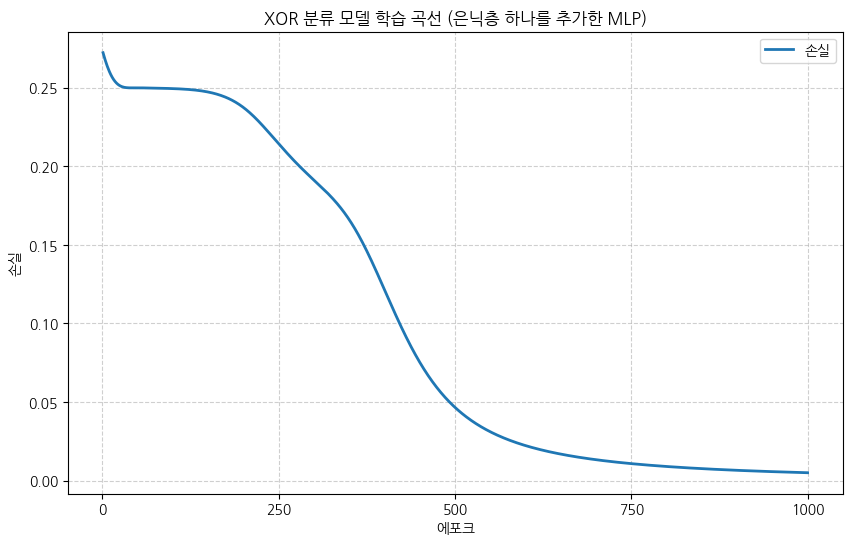

In [10]:
# 참고 - 학습 곡선 시각화 (EpochLogger 표준)
log.plot(title='XOR 분류 모델 학습 곡선 (은닉층 하나를 추가한 MLP)')

## 학습된 모델로 예측
- 모델의 출력값은 0~1 사이의 실수
    - 0.5 미만이면 0, 이상이면 1로 분류
- 파라미터 초깃값에 따라 결과는 달라질 수 있음

In [11]:
########################################################################################
# 코드 3-6 - XOR 게이트 시뮬레이터를 사용한 예측
########################################################################################

model.eval()                     # 평가 모드
with torch.no_grad():
    prediction = model(X)        # 예측
print(prediction)                

# 0.5를 문턱값으로 0과 1로 분류
classes = (prediction >= 0.5).int().flatten().tolist()
print(f'분류 결과: {classes}')   

tensor([[0.0593],
        [0.9324],
        [0.9336],
        [0.0877]])
분류 결과: [0, 1, 1, 0]


## 참고 - MLP 결과 분석

- 서로 다른 파라미터 초깃값으로 학습했을 때 은닉층 두 뉴런이 만드는 결정 경계 시각화([그림 3-8])
- 시드값을 1, 5로 주고 초기화한 두 모델
    - 시드값 1: 정상 분류 모델
    - 시드값 5: 오분류 모델

In [12]:
# 참고 - 시드값을 1과 5로 지정해 초기화한 두 XOR 분류 MLP 모델을 학습
import matplotlib.pyplot as plt

# XOR 데이터는 위에서 정의된 X, Y_true 를 그대로 사용
Y_label_list = Y_true.int().flatten().tolist()

# 주어진 시드로 초기화된 모델을 학습한 후 정답 수와 모델을 반환하는 함수
def train_and_eval(seed, epochs=1000, lr=0.01):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    model = MLP()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    for _ in range(epochs):
        pred = model(X)
        loss = criterion(pred, Y_true)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        pred = model(X)
        class_pred = (pred >= 0.5).int().flatten().tolist()
        correct_size = sum(int(a == b) for a, b in zip(class_pred, Y_label_list))
    return model, correct_size, class_pred

# 독자의 실습 환경에 따라 정상 분류, 오분류 시드는 달라질 수 있음
print('XOR 분류 MLP 모델 학습 결과(정답: [0, 1, 1, 0])')
candidate_seeds = [1, 5]
panel_labels = ['정상 분류', '오분류']
trained = []
for seed, label in zip(candidate_seeds, panel_labels):
    model, correct_size, class_pred = train_and_eval(seed)
    trained.append((seed, label, model, correct_size, class_pred))
    print(f'{label} (seed={seed}): {correct_size}/4 정답, 분류 결과 {class_pred}')

XOR 분류 MLP 모델 학습 결과(정답: [0, 1, 1, 0])
정상 분류 (seed=1): 4/4 정답, 분류 결과 [0, 1, 1, 0]
오분류 (seed=5): 2/4 정답, 분류 결과 [0, 1, 0, 1]


- 정상 분류 모델과 비정상 분류 모델의 은닉층 결정 경계 시각화
    - 데이터 공간에 시각화
    - 은닉층 뉴런 별 하나씩, 두 개의 직선 결정 경계
    - 가로 빗금만 있거나 세로 빗금만 있는 영역만 1로 분류되어야 함

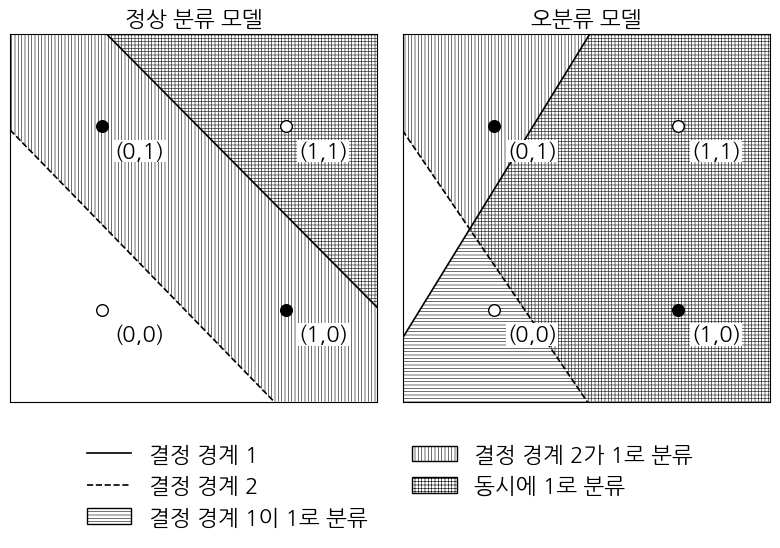

In [13]:
# 참고 - 정상 분류 모델과 비정상 분류 모델의 결정 경계 시각화([그림 3-8])
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

FIGURE_CASES = [(1, '정상 분류 모델'), (5, '오분류 모델')]
model_by_seed = {item[0]: item[2] for item in trained}   # 시드 -> 학습된 모델

# 은닉 뉴런의 출력이 0.5 이상인 영역 = 그 결정 경계가 1로 분류하는 영역
#       격자의 모든 점에 대해 두 은닉 뉴런의 출력을 계산해 영역을 판정
GRID_N = 300
grid_axis = np.linspace(-0.5, 1.5, GRID_N)
XX, YY = np.meshgrid(grid_axis, grid_axis)
grid_points = torch.tensor(np.stack([XX.ravel(), YY.ravel()], axis=1), dtype=torch.float32)

# 빗금 무늬: 결정 경계 1은 가로선, 결정 경계 2는 세로선
#     두 영역이 겹치는 부분: 두 빗금이 함께 그려진 격자 무늬로 표현
HATCHES = ['-----', '|||||']
LINE_STYLES = ['-', '--']
plt.rcParams['hatch.linewidth'] = 0.4

FONT_SIZE = 16

fig, axes = plt.subplots(1, 2, figsize=(8, 5.3))
for ax, (seed, title) in zip(axes, FIGURE_CASES):
    m = model_by_seed[seed]
    with torch.no_grad():
        hidden = m.activation(m.hidden_layer(grid_points)).numpy()
    weight = m.hidden_layer.weight.detach().numpy()      # (2, 2)
    bias = m.hidden_layer.bias.detach().numpy()          # (2,)

    # 은닉 뉴런별로 1로 분류하는 영역을 빗금으로 채움
    for j in range(2):
        region = hidden[:, j].reshape(GRID_N, GRID_N)
        contour = ax.contourf(
            XX, YY, region, levels=[0.5, 1.0],
            colors='none', hatches=[HATCHES[j]],
        )
        contour.set_edgecolor('black')
        contour.set_linewidth(0)

    # 은닉 뉴런별 결정 경계 직선
    for j in range(2):
        w1, w2, b = weight[j, 0], weight[j, 1], bias[j]
        if w2 == 0:
            ax.axvline(-b / w1, linestyle=LINE_STYLES[j], color='black',
                       linewidth=1.2)
        else:
            ax.plot(grid_axis, -(w1 / w2) * grid_axis - (b / w2),
                    linestyle=LINE_STYLES[j], color='black', linewidth=1.2)

    # XOR 데이터 네 점: 클래스 1은 채운 원, 클래스 0은 빈 원
    for (x1, x2), y in zip(X.tolist(), Y_label_list):
        ax.scatter(x1, x2, marker='o', s=70, zorder=3,
                   edgecolor='black', facecolor='black' if y == 1 else 'white')
        # 빗금 위에서도 읽히도록 좌표 표시에 흰색 배경을 깔아 준다
        ax.text(x1 + 0.07, x2 - 0.17, f'({int(x1)},{int(x2)})', fontsize=FONT_SIZE,
                bbox=dict(facecolor='white', edgecolor='none', pad=0.8))

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xticks([])            # 축의 값 표시 없음
    ax.set_yticks([])
    ax.set_aspect('equal')       # 두 축의 축척을 같게 맞춤
    ax.set_title(title, fontsize=FONT_SIZE)

# 그림 아래에 공통 범례 배치(빗금은 Patch 프록시로 표시)
legend_handles = [
    Line2D([0], [0], color='black', linewidth=1.2, label='결정 경계 1'),
    Line2D([0], [0], color='black', linewidth=1.2, linestyle='--',
           label='결정 경계 2'),
    Patch(facecolor='white', edgecolor='black', hatch=HATCHES[0],
          label='결정 경계 1이 1로 분류'),
    Patch(facecolor='white', edgecolor='black', hatch=HATCHES[1],
          label='결정 경계 2가 1로 분류'),
    Patch(facecolor='white', edgecolor='black', hatch=HATCHES[0] + HATCHES[1],
          label='동시에 1로 분류'),
]
fig.tight_layout(rect=[0, 0.25, 1, 1])
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           frameon=False, fontsize=FONT_SIZE)
plt.show()

- 출력층 결정 경계를 데이터 공간과 은닉 공간에 시각화
    - 데이터 공간: 등고선 형태의 곡선 결정 경계 형성(표시 범위를 크게 넓혀야 곡선으로 보임)
    - 은닉 공간: 직선 결정 경계

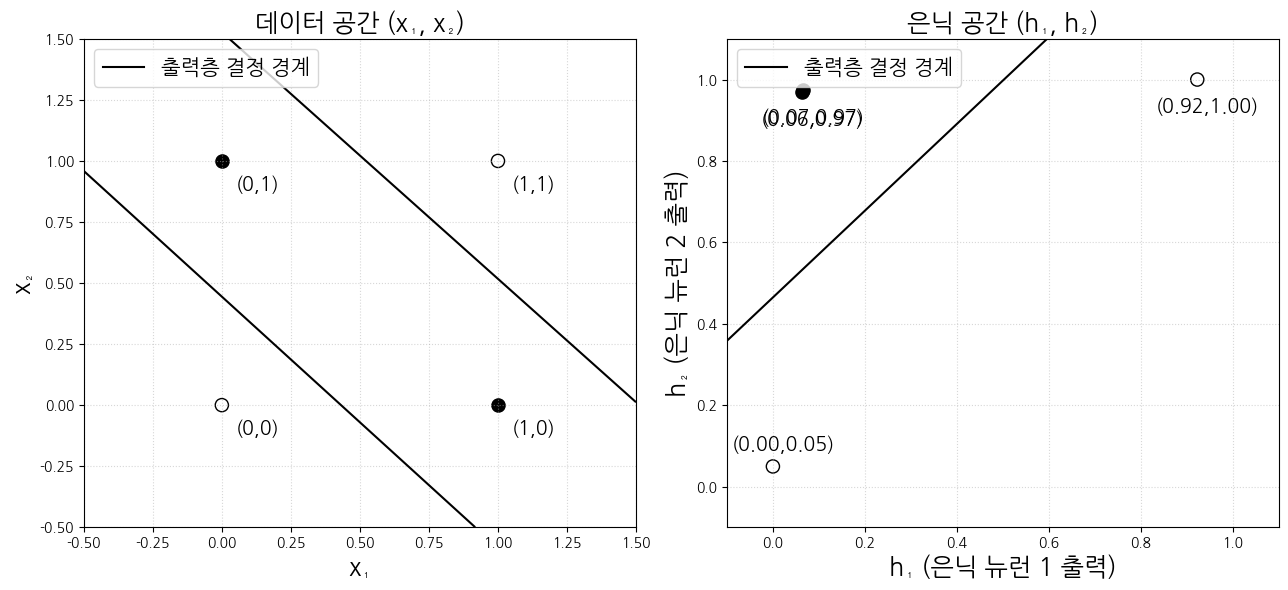

In [14]:
# 참고 - 정상 분류 모델의 데이터 공간과 은닉 공간에서의 출력층 결정 경계 시각화([그림 3-9])
from matplotlib.lines import Line2D

# 시드값 1인 모델
normal_model = trained[0][2]

with torch.no_grad():
    hw = normal_model.hidden_layer.weight.detach()     # (2, 2)
    hb = normal_model.hidden_layer.bias.detach()       # (2,)
    ow = normal_model.output_layer.weight.detach()     # (1, 2)
    ob = normal_model.output_layer.bias.detach()       # (1,)
    hidden_out = torch.sigmoid(X @ hw.T + hb)          # 은닉 공간 좌표 (4, 2)
ow_np = ow.numpy().flatten()
ob_np = ob.numpy().flatten()
ho_np = hidden_out.numpy()

FONT_SIZE = 18
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# 데이터 공간: 입력 격자에서 모델 출력 0.5 등고선으로 결정 경계 표시
ax = axes[0]
GRID_N = 200
xs = np.linspace(-0.5, 1.5, GRID_N)
ys = np.linspace(-0.5, 1.5, GRID_N)
XX, YY = np.meshgrid(xs, ys)
grid_pts = torch.tensor(
    np.stack([XX.ravel(), YY.ravel()], axis=1), dtype=torch.float32
)
normal_model.eval()
with torch.no_grad():
    grid_out = normal_model(grid_pts).numpy().reshape(GRID_N, GRID_N)
ax.contour(XX, YY, grid_out, levels=[0.5], colors='black', linewidths=1.5)
for x1, x2, y in zip([0., 1., 0., 1.], [0., 0., 1., 1.], Y_label_list):
    face = 'black' if y == 1 else 'none'
    ax.scatter(x1, x2, marker='o', s=90, edgecolor='black', facecolor=face)
    ax.text(x1 + 0.05, x2 - 0.12, f'({int(x1)},{int(x2)})', fontsize=14)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlabel('x₁', fontsize=FONT_SIZE)
ax.set_ylabel('x₂', fontsize=FONT_SIZE)
ax.set_title('데이터 공간 (x₁, x₂)', fontsize=FONT_SIZE)
ax.legend(handles=[Line2D([0], [0], color='black', linewidth=1.5,
                          label='출력층 결정 경계')],
          loc='upper left', fontsize=15)

# 은닉 공간: 4개 점을 은닉층 출력 (h1, h2) 좌표로 배치 (출력층은 선형)
ax = axes[1]
h_range = np.linspace(-0.1, 1.1, 400)
if ow_np[1] != 0:
    h2_line = -(ow_np[0] / ow_np[1]) * h_range - (ob_np[0] / ow_np[1])
    ax.plot(h_range, h2_line, color='black', linewidth=1.5,
            label='출력층 결정 경계')
else:
    ax.axvline(-ob_np[0] / ow_np[0], color='black', linewidth=1.5,
               label='출력층 결정 경계')
# 은닉 공간의 각 점은 데이터 공간의 입력이 옮겨진 위치이므로
# 은닉 공간 좌표 대신 원래 입력 (x1, x2) 로 표시해 두 공간을 대응시킨다
for i, ((h1, h2), y) in enumerate(zip(ho_np, Y_label_list)):
    x1, x2 = X[i].tolist()
    face = 'black' if y == 1 else 'none'
    ax.scatter(h1, h2, marker='o', s=90, edgecolor='black', facecolor=face)
    if i == 0:
        ax.text(h1 - 0.09, h2 + 0.04, f'({h1:.2f},{h2:.2f})', fontsize=14)
    else:
        ax.text(h1 - 0.09, h2 - 0.08, f'({h1:.2f},{h2:.2f})', fontsize=14)
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlabel('h₁ (은닉 뉴런 1 출력)', fontsize=FONT_SIZE)
ax.set_ylabel('h₂ (은닉 뉴런 2 출력)', fontsize=FONT_SIZE)
ax.set_title('은닉 공간 (h₁, h₂)', fontsize=FONT_SIZE)
ax.legend(loc='upper left', fontsize=15)
fig.tight_layout()
plt.show()